# Capstone Session 10

This notebook is generated from the copied `Capstone_Session_10.pdf` directions and the staged extracted image folders under `data/`.

## Objective

Build transfer-learning classifiers for face-mask detection, compare EfficientNetB0 and ResNet50, and save prediction evidence for the staged website workflow.

## Source Mismatch Note

The copied PDF calls for pre-existing `train/` and `test/` folders and a 3-neuron softmax head. The staged source only contains `data/with_mask` and `data/without_mask`, which is a 2-class dataset. This notebook creates generated `train/` and `test/` folders from the staged source and uses a 2-neuron softmax head so the model output matches the actual copied data.

## Runtime Scope Note

To keep the transfer-learning runs executable on the current CPU-only Windows environment, the generated split uses a fixed stratified sample from the staged image folders. The full extracted dataset remains staged in `data/`, and the split manifest is saved in `outputs/`.

In [1]:
from pathlib import Path
import json
import os
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.keras.utils.set_random_seed(42)
random.seed(42)

BASE_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Deep Learning Specialization/Capstone Session 10''')
SOURCE_DATA_DIR = BASE_DIR / 'data'
OUTPUTS_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Deep Learning Specialization/Capstone Session 10/outputs''')
PLOTS_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Deep Learning Specialization/Capstone Session 10/outputs/plots''')
GENERATED_SPLIT_DIR = OUTPUTS_DIR / 'generated_split'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
TRAIN_IMAGES_PER_CLASS = 120
TEST_IMAGES_PER_CLASS = 30

In [2]:
if GENERATED_SPLIT_DIR.exists():
    shutil.rmtree(GENERATED_SPLIT_DIR)

split_manifest = {'source_counts': {}, 'generated_counts': {}}
for split_name in ['train', 'test']:
    for class_name in ['with_mask', 'without_mask']:
        (GENERATED_SPLIT_DIR / split_name / class_name).mkdir(parents=True, exist_ok=True)

for class_name in ['with_mask', 'without_mask']:
    source_files = sorted([path for path in (SOURCE_DATA_DIR / class_name).iterdir() if path.is_file()])
    split_manifest['source_counts'][class_name] = len(source_files)
    random.shuffle(source_files)
    train_files = source_files[:TRAIN_IMAGES_PER_CLASS]
    test_files = source_files[TRAIN_IMAGES_PER_CLASS:TRAIN_IMAGES_PER_CLASS + TEST_IMAGES_PER_CLASS]
    split_manifest['generated_counts'][class_name] = {'train': len(train_files), 'test': len(test_files)}
    for file_path in train_files:
        shutil.copy2(file_path, GENERATED_SPLIT_DIR / 'train' / class_name / file_path.name)
    for file_path in test_files:
        shutil.copy2(file_path, GENERATED_SPLIT_DIR / 'test' / class_name / file_path.name)

with open(OUTPUTS_DIR / 'session_10_split_manifest.json', 'w', encoding='utf-8') as handle:
    json.dump(split_manifest, handle, indent=2)
split_manifest

{'source_counts': {'with_mask': 3725, 'without_mask': 3828},
 'generated_counts': {'with_mask': {'train': 120, 'test': 30},
  'without_mask': {'train': 120, 'test': 30}}}

In [3]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0, validation_split=0.2)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    GENERATED_SPLIT_DIR / 'train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
)
validation_generator = train_datagen.flow_from_directory(
    GENERATED_SPLIT_DIR / 'train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
)
test_generator = test_datagen.flow_from_directory(
    GENERATED_SPLIT_DIR / 'test',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)
class_indices = train_generator.class_indices
class_labels = {index: label for label, index in class_indices.items()}
class_indices

Found 192 images belonging to 2 classes.


Found 48 images belonging to 2 classes.


Found 60 images belonging to 2 classes.


{'with_mask': 0, 'without_mask': 1}

In [4]:
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=0),
]

def build_transfer_model(base_model_name):
    if base_model_name == 'EfficientNetB0':
        preprocess = tf.keras.applications.efficientnet.preprocess_input
        base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
        dropout_rate = 0.2
    elif base_model_name == 'ResNet50':
        preprocess = tf.keras.applications.resnet50.preprocess_input
        base_model = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
        dropout_rate = 0.5
    else:
        raise ValueError(base_model_name)

    base_model.trainable = False
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3)),
        tf.keras.layers.Lambda(preprocess),
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(2, activation='softmax'),
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [5]:
histories = {}
evaluations = []
prediction_examples = {}
for model_name in ['EfficientNetB0', 'ResNet50']:
    tf.keras.backend.clear_session()
    train_generator.reset()
    validation_generator.reset()
    test_generator.reset()
    model = build_transfer_model(model_name)
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=25,
        callbacks=callbacks,
        verbose=0,
    )
    histories[model_name] = pd.DataFrame(history.history)
    test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
    test_generator.reset()
    probabilities = model.predict(test_generator, verbose=0)
    predicted_labels = np.argmax(probabilities, axis=1)
    true_labels = test_generator.classes.copy()
    evaluations.append({
        'model': model_name,
        'epochs_ran': int(len(histories[model_name])),
        'test_loss': float(test_loss),
        'test_accuracy': float(test_accuracy),
    })
    prediction_examples[model_name] = {
        'filenames': test_generator.filenames[:10],
        'true_labels': [class_labels[index] for index in true_labels[:10]],
        'predicted_labels': [class_labels[index] for index in predicted_labels[:10]],
    }
evaluations_df = pd.DataFrame(evaluations).sort_values('test_accuracy', ascending=False).reset_index(drop=True)
evaluations_df

       0/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  679936/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

 2555904/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

 5292032/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 6815744/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

...

90390528/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

92323840/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

94273536/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


,model,epochs_ran,test_loss,test_accuracy
0,ResNet50,25,0.688841,0.55
1,EfficientNetB0,24,0.693286,0.50


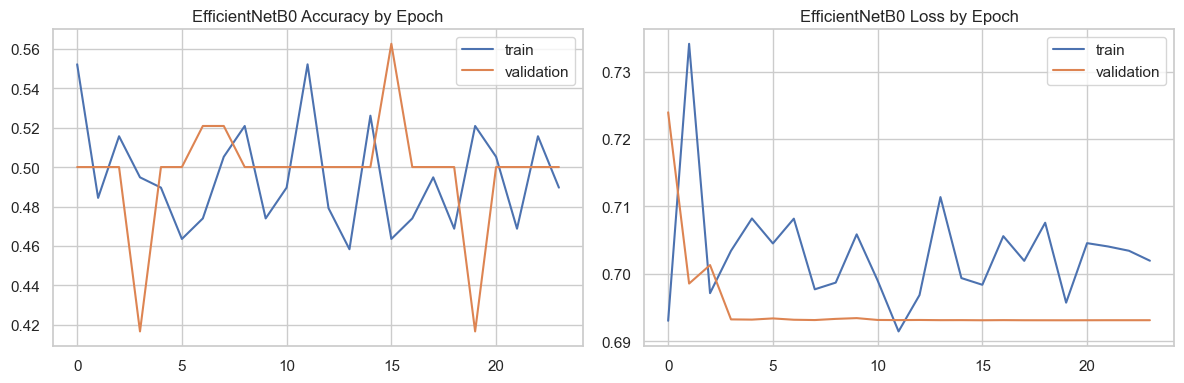

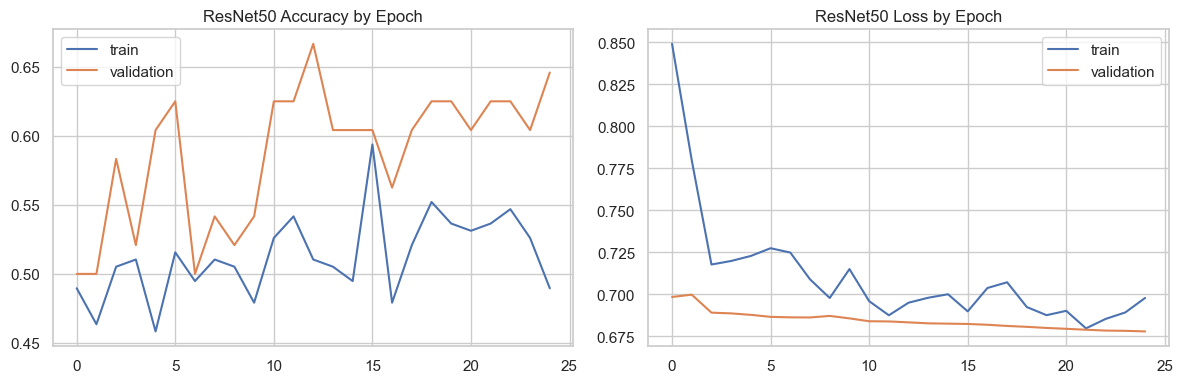

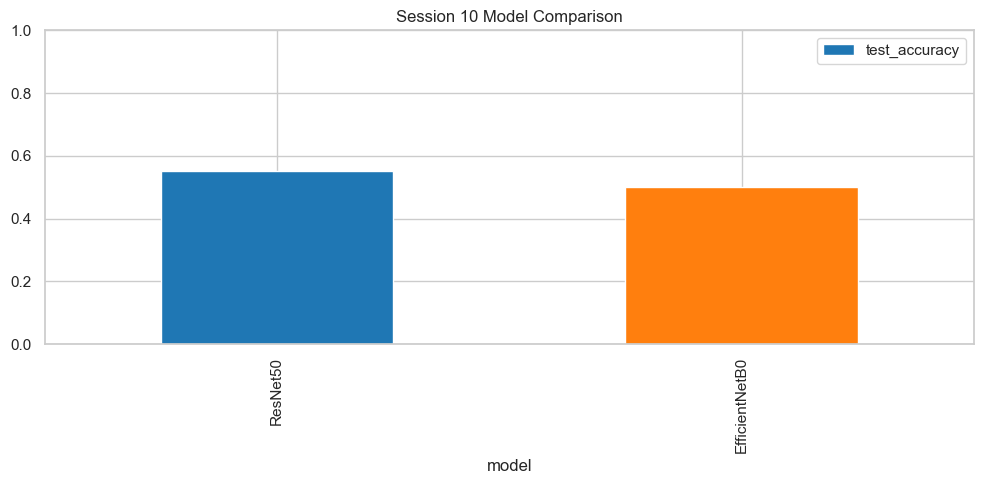

In [6]:
for model_name, history_df in histories.items():
    history_df.to_csv(OUTPUTS_DIR / f'{model_name.lower()}_history.csv', index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['accuracy'], label='train')
    axes[0].plot(history_df['val_accuracy'], label='validation')
    axes[0].set_title(f'{model_name} Accuracy by Epoch')
    axes[0].legend()
    axes[1].plot(history_df['loss'], label='train')
    axes[1].plot(history_df['val_loss'], label='validation')
    axes[1].set_title(f'{model_name} Loss by Epoch')
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / f'{model_name.lower()}_training_history.png', dpi=150)
    plt.show()
    plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
evaluations_df.plot(x='model', y='test_accuracy', kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title('Session 10 Model Comparison')
ax.set_ylim(0, 1.0)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'model_comparison.png', dpi=150)
plt.show()
plt.close(fig)

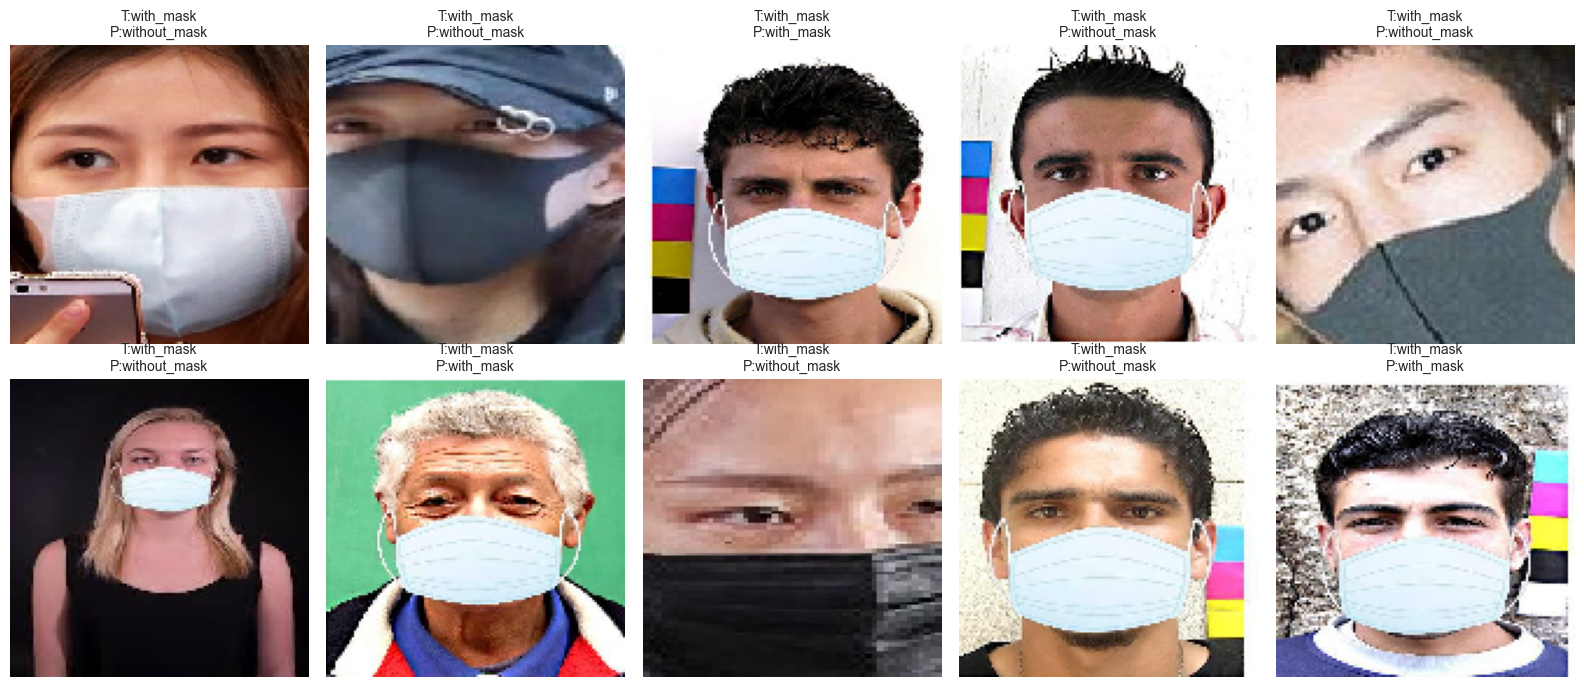

In [7]:
best_model_name = evaluations_df.iloc[0]['model']
example_info = prediction_examples[best_model_name]
figure, axes = plt.subplots(2, 5, figsize=(16, 7))
for axis, filename, true_label, predicted_label in zip(axes.flatten(), example_info['filenames'], example_info['true_labels'], example_info['predicted_labels']):
    image_path = GENERATED_SPLIT_DIR / 'test' / filename
    image = tf.keras.utils.load_img(image_path, target_size=IMAGE_SIZE)
    axis.imshow(image)
    axis.set_title(f'T:{true_label}\nP:{predicted_label}', fontsize=10)
    axis.axis('off')
figure.tight_layout()
figure.savefig(PLOTS_DIR / 'best_model_prediction_examples.png', dpi=150)
plt.show()
plt.close(figure)

In [8]:
evaluations_df.to_csv(OUTPUTS_DIR / 'session_10_model_comparison.csv', index=False)
summary = {
    'source_counts': split_manifest['source_counts'],
    'generated_counts': split_manifest['generated_counts'],
    'class_indices': class_indices,
    'pdf_mismatch_notes': [
        'The copied PDF expects train/test folders, but the staged source only provided data/with_mask and data/without_mask.',
        'The copied PDF expects a 3-neuron softmax head, but the staged source is a 2-class dataset, so the executed models use a 2-neuron softmax head.',
        'The generated train/test split is a fixed stratified sample to keep transfer-learning runs executable on the current CPU-only environment.',
    ],
    'model_results': evaluations,
    'best_model': evaluations_df.iloc[0].to_dict(),
    'best_model_example_predictions': prediction_examples[best_model_name],
}
with open(OUTPUTS_DIR / 'session_10_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary

{'source_counts': {'with_mask': 3725, 'without_mask': 3828},
 'generated_counts': {'with_mask': {'train': 120, 'test': 30},
  'without_mask': {'train': 120, 'test': 30}},
 'class_indices': {'with_mask': 0, 'without_mask': 1},
 'pdf_mismatch_notes': ['The copied PDF expects train/test folders, but the staged source only provided data/with_mask and data/without_mask.',
  'The copied PDF expects a 3-neuron softmax head, but the staged source is a 2-class dataset, so the executed models use a 2-neuron softmax head.',
  'The generated train/test split is a fixed stratified sample to keep transfer-learning runs executable on the current CPU-only environment.'],
 'model_results': [{'model': 'EfficientNetB0',
   'epochs_ran': 24,
   'test_loss': 0.693286120891571,
   'test_accuracy': 0.5},
  {'model': 'ResNet50',
   'epochs_ran': 25,
   'test_loss': 0.6888409852981567,
   'test_accuracy': 0.550000011920929}],
 'best_model': {'model': 'ResNet50',
  'epochs_ran': 25,
  'test_loss': 0.68884098529